# Skip-Gram Word2Vec Implmentation from Scratch

## Register Number: 23BAI1589 - Yashvanth Karunakaran

### AIM:

To implement the skipgram variant of Word2Vec using negative sampling, subsampling, dynamic window and learning rate decay.


#### Skipgram:
it is a variation of word2vec, given a target word we can find the context words.

Eg:
yashvanth like backend projects

given context window = 2 and input as backend

the output will be [like,projects]

#### Negative sampling:
instead of using softmax probability for all pairs (due to large vocabulary), it is efficient to use negative sampling which means we give real pairs (here: (backend,projects)) along with that give k-negative pairs to train a classifier, such that positive pairs will get high score and negative pair will get low score. we randomly initialize vector for both target word and context word and while training we move positive pair vectors closer and negative pair vectors farther.

In [2]:
!pip3 install numpy tqdm requests matplotlib scikit-learn scipy -q

### Downloading and Loading Text8 Dataset


In [3]:
import requests
import zipfile
import io

url="http://mattmahoney.net/dc/text8.zip"
response=requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall()

In [4]:
with open("text8", "r") as f:
    corpus=f.read().split()
total_words=len(corpus)

print("Total Words:",total_words)
print("First 50 words:",' '.join(corpus[:50]))
print("Last 50 words:",' '.join(corpus[-50:]))

Total Words: 17005207
First 50 words: anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english revolution and the sans culottes of the french revolution whilst the term is still used in a pejorative way to describe any act that used violent means to destroy the
Last 50 words: elazar ben yair s final exortation to his followers prior to the mass suicide verbatim to the romans the site today platform access to the fortress the site of masada was identified in one eight four two and extensively excavated in one nine six three one nine six five b


### Building Vocabulary
considering words with frequency only greater than or equal to 5 are considered for improving accuracy and for more training data for words.


In [5]:
from collections import Counter

word_counts=Counter(corpus)

MIN_COUNT=5
word_counts={w:c for w,c in word_counts.items() if c>=MIN_COUNT}

vocab=list(word_counts.keys())
v=len(vocab)

print("Vocabulary Size:",v)

Vocabulary Size: 71290


### Checking most common words


In [6]:
print("Top 20 most common words:")
for word,count in sorted(word_counts.items(),key=lambda x:x[1],reverse=True)[:20]:
    print(f"{word} {count} occurrences")

Top 20 most common words:
the 1061396 occurrences
of 593677 occurrences
and 416629 occurrences
one 411764 occurrences
in 372201 occurrences
a 325873 occurrences
to 316376 occurrences
zero 264975 occurrences
nine 250430 occurrences
two 192644 occurrences
is 183153 occurrences
as 131815 occurrences
eight 125285 occurrences
for 118445 occurrences
s 116710 occurrences
five 115789 occurrences
three 114775 occurrences
was 112807 occurrences
by 111831 occurrences
that 109510 occurrences


### Creating word-to-index mappings

using this mapping to access the embeddings for respective words


In [7]:
word2id={w: i for i,w in enumerate(vocab)}
id2word={i:  w for w,i in word2id.items()}

sample_words=list(word2id.keys())[:10]
for word in sample_words:
    print(word," id: ",word2id[word])

anarchism  id:  0
originated  id:  1
as  id:  2
a  id:  3
term  id:  4
of  id:  5
abuse  id:  6
first  id:  7
used  id:  8
against  id:  9


In [8]:
print("Vocabulary size initially:",len(Counter(corpus)))
print("no. of words removed after min frequency limit:",len(Counter(corpus))-v)

Vocabulary size initially: 253854
no. of words removed after min frequency limit: 182564


### Discarding Frequent words
Frequent words (like "the", "a") provide less information. Subsampling balances the dataset
#### Formula: P(keep) = 1 - sqrt(threshold / frequency)

threshold here is 10e-5

In [9]:
import math

SUBSAMPLE_THRESHOLD=1e-5

word_freq={w:c/total_words for w,c in word_counts.items()}

subsample_prob={w:max(0,1-math.sqrt(SUBSAMPLE_THRESHOLD/word_freq[w])) for w in word_freq}

sample_words = ['the','of','and','one']
for word in sample_words:
    if word in word_freq:
        freq=word_freq[word]
        discard=subsample_prob[word]
        keep=1-discard
        counts=word_counts[word]
        print(f"Word: {word}, Count: {counts}, Frequency: {freq:.3f}, Discard Prob: {discard:.3f}, Keep Prob: {keep:.3f}")

Word: the, Count: 1061396, Frequency: 0.062, Discard Prob: 0.987, Keep Prob: 0.013
Word: of, Count: 593677, Frequency: 0.035, Discard Prob: 0.983, Keep Prob: 0.017
Word: and, Count: 416629, Frequency: 0.025, Discard Prob: 0.980, Keep Prob: 0.020
Word: one, Count: 411764, Frequency: 0.024, Discard Prob: 0.980, Keep Prob: 0.020


In [10]:
import random

random.seed(42)

subsampled_corpus = []
for w in subsample_prob.keys():
        if random.random()>subsample_prob[w]:
            subsampled_corpus.append(w)

print("Original corpus size:",total_words)
print("After subsampling:",len(subsampled_corpus))

Original corpus size: 17005207
After subsampling: 68231


#### Configuring Dataset size

In [11]:
MAX_TOKENS=100000
subsampled_corpus=subsampled_corpus[:MAX_TOKENS]

### Negative sampling distribution
instead of updating all word vectors, updating only few negative samples, using unigram distribution raised to power 0.75 so that more weight is given to rare words compared to uniform sampling,

#### Formula: P(w) proportional to freq(w)^0.75

In [12]:
import numpy as np

neg_sampling_dist = np.array([word_counts[id2word[i]]**0.75 for i in range(v)])

neg_sampling_dist/=neg_sampling_dist.sum()

neg_sampling_dist

array([3.24104708e-05, 5.21975825e-05, 3.08728692e-03, ...,
       1.71086919e-06, 1.49221318e-06, 1.92055566e-06], shape=(71290,))

### Initializing Word Embeddings

Creating random initial embeddings for input and output layers with dimensions 300. W_in is used for target word. W_out is used for context words. Initially initialized with small random values.

In [13]:
EMBEDDING_DIM=300

np.random.seed(42)

W_in=np.random.uniform(-0.01,0.01,(v,EMBEDDING_DIM))
W_out=np.random.uniform(-0.01,0.01,(v,EMBEDDING_DIM))

### Helper Functions - Sigmoid and Context Window

Defining sigmoid activation function and dynamic context window selection for training. Window size randomly chosen from 1 to WINDOW_SIZE

In [14]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

WINDOW_SIZE=3

def get_context_words(corpus,idx):
    window=random.randint(1,WINDOW_SIZE)
    
    start = max(0,idx-window)
    end = min(len(corpus),idx+window+1)
    
    return [corpus[i] for i in range(start,end) if i!=idx]

### Testing Context Window Function

Verifying that the context window function correctly extracts surrounding words

In [15]:
test_corpus="Yashvanth is very good at software development agile tasks".split()
target_idx=5

get_context_words(test_corpus,target_idx)

['good', 'at', 'development', 'agile']

### Training Configuration

Setting hyperparameters for training: epochs, negative samples, learning rate schedule, and loss tracking

In [16]:
EPOCHS=10
NEGATIVE_SAMPLES=10
INITIAL_LR=0.025
MIN_LR=0.0001
LOSS_LOG_INTERVAL=1000

losses=[]
epoch_losses=[]
learning_rates=[]

steps=len(subsampled_corpus)*EPOCHS
step=0

### Training Skip-Gram Model with Negative Sampling

Training the Word2Vec model by optimizing embeddings through backpropagation with dynamic learning rate decay

<br>
1. iterating over epochs (i considered 10 epochs)<br>
2. shuffled the corpus so the model see words in different order in each epoch<br>
3. iterating through each word, treating it as a target word<br>
4. learning rate decay, starting with initial_lr and gradually decaying it linearly and never making it go below min_lr<br>
5. for each context word computing the positive sample loss and gradient, sample negative words computing loss and gradient, updating the context and negative embeddings immediately<br>
6. updating the target embedding after all negative<br>
7. tracking loss and learning rate for monitoring<br>
8. printing the average epoch loss to see training progress

#### formula i used here:
Vw: input embedding vector for word w (from W_in)<br>
Uw: output embedding vector for word w (from W_out)<br>
sigmod(x): 1/(1+exp(-x))<br>
Wt: target word<br>
Wc: context word (+ve)<br>
Wk: negative sample word<br>
N: number of negative samples<br>

positive sample loss<br>
scorepos = sigmoid(Vw.Uw)<br>
LOSSpos = -log(scorepos) = -log(sigmoid(Vw.Uw))<br>
gradient of loss w.r.t target embedding = gradient(LOSSpos,Vw) = (sigmoid(Vw.Uw)-1)Uw<br>
gradient of loss w.r.t context embedding = gradient(LOSSpos,Uw) = (sigmoid(Vw.Uw)-1)Vw<br>

negative sample loss<br>
scoreneg = sigmoid(Vw.Uw)
LOSSpos = -log(score) = -log(1-scoreneg)<br>
gradient of loss w.r.t target embedding = gradient(LOSSpos,Vw) = scoreneg.Uw<br>
gradient of loss w.r.t context embedding = gradient(LOSSpos,Uw) = scoreneg.Vw<br>

total loss<br>
LOSStarget = sum(-log(scorepos)) + sum(-log(1-scoreneg))<br>

target embedding updation<br>
Vw = Vw - alpha.(gradient(LOSStarget))

In [17]:
from tqdm import tqdm
import numpy as np
import random

for epoch in range(EPOCHS):
    random.shuffle(subsampled_corpus)
    epoch_loss=0

    for i,target_word in enumerate(tqdm(subsampled_corpus,desc=f"Epoch {epoch+1}")):
        step+=1

        lr=max(INITIAL_LR*(1-step/steps),MIN_LR)

        target_id=word2id[target_word]
        v_target=W_in[target_id].copy()

        context_words=get_context_words(subsampled_corpus, i)

        grad_target=np.zeros(EMBEDDING_DIM)
        sample_loss=0

        for context_word in context_words:
            context_id=word2id[context_word]
            u_context=W_out[context_id]

            score_pos=sigmoid(np.dot(v_target,u_context))
            sample_loss+=-np.log(score_pos+1e-10)

            grad_pos=score_pos-1
            grad_target+=grad_pos*u_context
            W_out[context_id]-=lr*grad_pos*v_target

            neg_ids=np.random.choice(v,size=NEGATIVE_SAMPLES,
replace=False,p=neg_sampling_dist)

            for neg_id in neg_ids:
                if neg_id==context_id:
                    continue

                u_neg=W_out[neg_id]
                score_neg=sigmoid(np.dot(v_target,u_neg))
                sample_loss+=-np.log(1-score_neg+1e-10)

                grad_neg=score_neg
                grad_target+=grad_neg*u_neg
                W_out[neg_id]+=lr*grad_neg*v_target

        W_in[target_id]-=lr*grad_target

        epoch_loss+=sample_loss
        
        if step%LOSS_LOG_INTERVAL==0:
            losses.append(sample_loss)
            learning_rates.append(lr)


    avg_loss=epoch_loss/len(subsampled_corpus)
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Avg Loss: {avg_loss:.4f}")


Epoch 1: 100%|██████████| 68231/68231 [02:41<00:00, 423.55it/s]


Epoch 1/10 | Avg Loss: 30.4494


Epoch 2: 100%|██████████| 68231/68231 [02:41<00:00, 423.19it/s]


Epoch 2/10 | Avg Loss: 30.5534


Epoch 3: 100%|██████████| 68231/68231 [02:40<00:00, 426.01it/s]


...

Epoch 8/10 | Avg Loss: 34.1467


Epoch 9: 100%|██████████| 68231/68231 [02:36<00:00, 435.38it/s]


Epoch 9/10 | Avg Loss: 29.1592


Epoch 10: 100%|██████████| 68231/68231 [02:40<00:00, 425.24it/s]

Epoch 10/10 | Avg Loss: 27.4382


### Visualizing Training Loss

Plotting the loss values across training steps to monitor model convergence

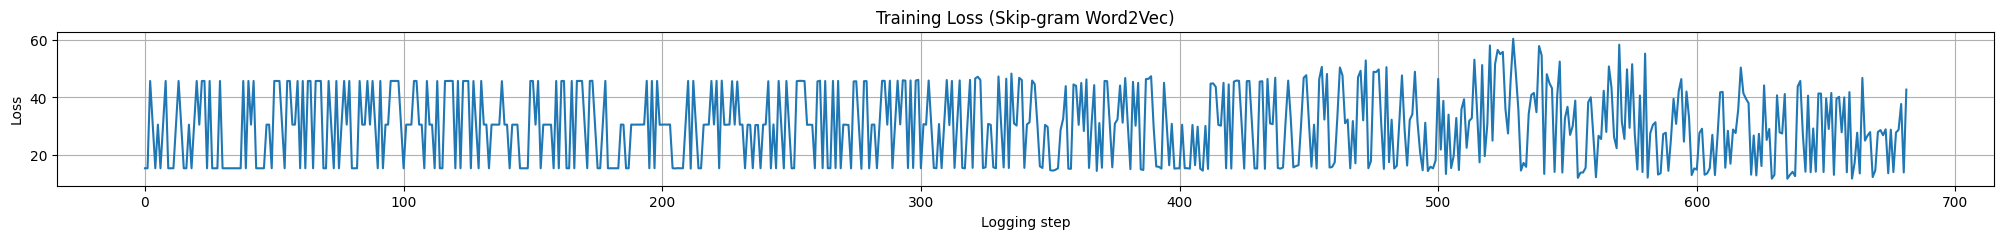

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25,2))
plt.plot(losses)
plt.xlabel("Logging step")
plt.ylabel("Loss")
plt.title("Training Loss (Skip-gram Word2Vec)")
plt.grid(True)
plt.show()

### Epoch-wise Loss Analysis

Showing average loss for each epoch to track overall training progress

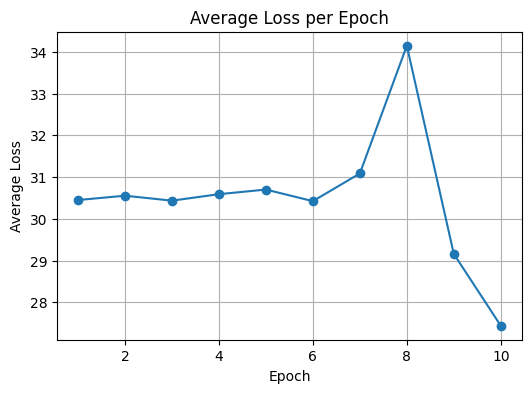

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Average Loss per Epoch")
plt.grid(True)
plt.show()

### Helper function for finding cosine similarity and most_similar words

In [20]:
def cosine_similarity(x,y):
    norm1=np.linalg.norm(x)
    norm2=np.linalg.norm(y)
    if norm1==0 or norm2==0:
        return 0.0
    return np.dot(x,y)/(norm1*norm2)

def most_similar(word, topn=10):
    if word not in word2id:
        print(f"Word '{word}' not in vocabulary")
        return []
    
    word_idx=word2id[word]
    word_vec=W_in[word_idx]
    
    word_vec_norm=word_vec/(np.linalg.norm(word_vec)+1e-10)

    similarities=[]
    for i in range(v):
        if i!=word_idx:
            other_vec=W_in[i]
            other_vec_norm=other_vec/(np.linalg.norm(other_vec)+1e-10)
            sim=np.dot(word_vec_norm,other_vec_norm)
            similarities.append((id2word[i],sim))
    
    similarities.sort(key=lambda x: x[1],reverse=True)
    
    return similarities[:topn]

### Finding Similar Words

Computing cosine similarity to find the most similar words to a given word based on learned embeddings

In [25]:
test_words=['king','queen','dog','man','woman','computer']

for word in test_words:
    print(f"Most similar words to '{word}': ")
    print(f"{'Rank'} {'Word'} {'Similarity'}")
    
    similar_words=most_similar(word,topn=10)
    for i,(similar_word, similarity) in enumerate(similar_words,1):
        print(f"{i}. {similar_word} {similarity:.4f}")
    print()

Most similar words to 'king': 
Rank Word Similarity
1. prancing 0.2058
2. mature 0.1950
3. number 0.1836
4. debuting 0.1787
5. hits 0.1787
6. computers 0.1763
7. important 0.1739
8. armies 0.1678
9. formerly 0.1660
10. be 0.1636

Most similar words to 'queen': 
Rank Word Similarity
1. rice 0.2197
2. broadway 0.2099
3. environment 0.1847
4. poincar 0.1826
5. ensign 0.1785
6. korea 0.1771
7. aimed 0.1721
8. kalam 0.1673
9. germans 0.1671
10. options 0.1641

Most similar words to 'dog': 
Rank Word Similarity
1. feeds 0.1930
2. ratios 0.1851
3. microsoft 0.1840
4. acid 0.1788
5. trigonal 0.1771
6. vibrating 0.1768
7. curve 0.1764
8. argentina 0.1755
9. mission 0.1717
10. disdainful 0.1707

Most similar words to 'man': 
Rank Word Similarity
1. quench 0.7969
2. hakama 0.7958
3. tachycardia 0.7951
4. sued 0.7944
5. chaser 0.7934
6. pakalitha 0.7926
7. handfastings 0.7921
8. scotus 0.7916
9. liebowitz 0.7906
10. shotcrete 0.7906

Most similar words to 'woman': 
Rank Word Similarity
1. deity 0.

### Analyzing Word Embeddings

Inspecting and comparing the learned embeddings and similarities between specific words

In [22]:
word1='king'
word2='queen'
word3='sandal'

id1 = word2id[word1]
id2 = word2id[word2]
id3 = word2id[word3]

embed1 = W_in[id1]
embed2 = W_in[id2]
embed3 = W_in[id3]

print(f"Word: {word1}")
print(f"Embedding shape: {embed1.shape}")
print(f"First 20 dimensions: {embed1[:20]}")
print(f"Embedding norm: {np.linalg.norm(embed1):.4f}")
print()

print(f"Word: {word2}")
print(f"Embedding shape: {embed2.shape}")
print(f"First 20 dimensions: {embed2[:20]}")
print(f"Embedding norm: {np.linalg.norm(embed2):.4f}")
print()
    
print(f"Word: {word3}")
print(f"Embedding shape: {embed3.shape}")
print(f"First 20 dimensions: {embed3[:20]}")
print(f"Embedding norm: {np.linalg.norm(embed3):.4f}")
print()

sim = cosine_similarity(embed1, embed2)
print(f"Cosine similarity between '{word1}' and '{word2}': {sim:.4f}")

sim = cosine_similarity(embed1, embed3)
print(f"Cosine similarity between '{word1}' and '{word3}': {sim:.4f}")

Word: king
Embedding shape: (300,)
First 20 dimensions: [ 0.00569674 -0.00775773 -0.00237859  0.0054912  -0.00165317  0.00944731
  0.00471481 -0.00969     0.00759971 -0.0079839  -0.00718953  0.00468985
  0.00729937  0.00072699 -0.00421901 -0.00297369 -0.00314221 -0.00346644
 -0.00514181  0.00217734]
Embedding norm: 0.0975

Word: queen
Embedding shape: (300,)
First 20 dimensions: [ 0.0098824   0.00570311  0.00376395  0.00490319 -0.008511   -0.00943019
 -0.00577521  0.00809129  0.00345067  0.0080616   0.00145591  0.00998689
 -0.00858213  0.00485335 -0.0069106  -0.00254241 -0.00532625 -0.00110889
  0.0018677  -0.00615873]
Embedding norm: 0.1001

Word: sandal
Embedding shape: (300,)
First 20 dimensions: [ 0.01814571  0.00666324 -0.01384741  0.01461798  0.01229799 -0.02195046
  0.01267317 -0.02177773  0.00832977 -0.00328735 -0.00658064  0.00806742
  0.01468988 -0.00338191  0.01046488 -0.01543763 -0.00454536 -0.00870041
 -0.02120312  0.00845156]
Embedding norm: 0.2565

Cosine similarity betw